# Aperture Photometry for SED Fitting

In this notebook, we'll measure integrated multiwavelength fluxes for NGC 4321. These fluxes can then be inputted into SED-fitting codes such as CIGALE or Bagpipes. 

Our main goals are: 
1. Load the cleaned images from the first notebook. 
2. Make cutouts centered on NGC 4321 using `Cutout2D`.
3. Define a matched aperture on the sky. 
4. Add aperture-specific masks for bright stars near the disk and nearby galaxies. 
5. Measure aperture fluxes using Photutils. 
6. Propagate uncertainties, including: 
    - random/background uncertainty
    - calibration uncertainty
7. Convert the fluxes into:
    - Jy
    - mJy
    - erg/s/cm<sup>2</sup>/Å
    - erg/s/cm<sup>2</sup>/Hz
    - AB magnitudes
8. Save a science table and a CIGALE-formatted input file. 

Remember that the images have units of Jy/pix. Because aperture photometry sums over pixels, the integrated aperture flux has units of Jy. 

In [15]:
# Numerical tools
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# File paths
from pathlib import Path

# FITS, WCS, coordinates, units, tables
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
from astropy.table import Table, QTable
import astropy.units as u

# Cutouts
from astropy.nddata import Cutout2D

# Image visualization
from astropy.visualization import ImageNormalize, PercentileInterval, AsinhStretch

# Photutils aperture photometry
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry

# Sigma clipping
from astropy.stats import sigma_clip

# Plot defaults
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 12

## 1. Define the Data Set

Just as before, we need to define the images we want to use. Each row of our image table will include:
- `band`: the short name we use in this notebook
- `instrument`: the telescope
- `wavelength_um`: the wavelength of the filter in microns
- `psf_fwhm_arcsec`: the approximate PSF FWHM
- `cigale_filter`: the filter-column name to use in the CIGALE input file
- `filename`: the cleaned FITS file from the first notebook
- `usable`: whether to include the band

Assuming you have CIGALE downloaded on your computer and ready to run, you can run

```bash
pcigale-filters list
```

to list out all of the filters available and their names. 

In [16]:
# Directory created by the first notebook
processed_dir = Path('NGC4321_BkgSub')

# Directory for products from this notebook
output_dir = Path('NGC4321_AperturePhotometry')
output_dir.mkdir(exist_ok=True)

# Center of NGC 4321
target_name = 'NGC4321'
target_coord = SkyCoord(ra=185.728590*u.deg, dec=15.821635*u.deg, frame='icrs')

galaxy_distance_mpc = 15.8
galaxy_redshift = 0.0

# AB zero-point flux density
AB_ZEROPOINT_JY = 3631.0

# Table for the image files
image_table = Table(
    names=['band','instrument','wavelength_um','psf_fwhm_arcsec','cigale_filter','filename','usable','notes'],
    dtype=['U20','U20',float,float,'U40','U200',bool,'U100']
)

# GALEX
image_table.add_row(('FUV', 'GALEX', 0.153508, 4.3, 'galex.FUV', str(processed_dir / 'NGC4321_GALEX_FUV_bkgsub.fits'), True, 'Far-UV: young massive stars'))
image_table.add_row(('NUV', 'GALEX', 0.230078, 5.3, 'galex.NUV', str(processed_dir / 'NGC4321_GALEX_NUV_bkgsub.fits'), True, 'Near-UV: recent star formation'))

# SDSS
image_table.add_row(('u', 'SDSS', 0.350102, 1.3, 'sloan.sdss.u', str(processed_dir / 'NGC4321_SDSS_u_bkgsub.fits'), True, 'Blue optical / young stars'))
image_table.add_row(('g', 'SDSS', 0.476311, 1.3, 'sloan.sdss.g', str(processed_dir / 'NGC4321_SDSS_g_bkgsub.fits'), True, 'Optical stellar light'))
image_table.add_row(('r', 'SDSS', 0.624698, 1.3, 'sloan.sdss.r', str(processed_dir / 'NGC4321_SDSS_r_bkgsub.fits'), True, 'Optical stellar light'))
image_table.add_row(('i', 'SDSS', 0.771828, 1.3, 'sloan.sdss.i', str(processed_dir / 'NGC4321_SDSS_i_bkgsub.fits'), True, 'Older stars, less dust-sensitive'))
image_table.add_row(('z', 'SDSS', 1.082983, 1.3, 'sloan.sdss.z', str(processed_dir / 'NGC4321_SDSS_z_bkgsub.fits'), True, 'Red optical / old stars'))

# 2MASS
image_table.add_row(('J', '2MASS', 1.235000, 2.0, '2mass.J', str(processed_dir / 'NGC4321_2MASS_J_bkgsub.fits'), True, 'Near-IR stellar mass tracer'))
image_table.add_row(('H', '2MASS', 1.662000, 2.0, '2mass.H', str(processed_dir / 'NGC4321_2MASS_H_bkgsub.fits'), True, 'Near-IR stellar mass tracer'))
image_table.add_row(('Ks', '2MASS', 2.159000, 2.0, '2mass.Ks', str(processed_dir / 'NGC4321_2MASS_Ks_bkgsub.fits'), True, 'Near-IR stellar mass tracer'))

# Spitzer
image_table.add_row(('IRAC1', 'Spitzer', 3.537841, 1.66, 'spitzer.irac.I1', str(processed_dir / 'NGC4321_Spitzer_IRAC1_bkgsub.fits'), True, 'Old stars + hot dust'))
image_table.add_row(('IRAC2', 'Spitzer', 4.478049, 1.72, 'spitzer.irac.I2', str(processed_dir / 'NGC4321_Spitzer_IRAC2_bkgsub.fits'), True, 'Old stars + hot dust'))
image_table.add_row(('IRAC3', 'Spitzer', 5.696178, 1.88, 'spitzer.irac.I3', str(processed_dir / 'NGC4321_Spitzer_IRAC3_bkgsub.fits'), True, 'PAH + warm dust'))
image_table.add_row(('IRAC4', 'Spitzer', 7.797840, 1.98, 'spitzer.irac.I4', str(processed_dir / 'NGC4321_Spitzer_IRAC4_bkgsub.fits'), True, 'PAH + warm dust'))
image_table.add_row(('MIPS24', 'Spitzer', 23.593478, 6.0, 'spitzer.mips.24mu', str(processed_dir / 'NGC4321_Spitzer_MIPS24_bkgsub.fits'), True, 'Warm dust + embedded star formation'))
image_table.add_row(('MIPS160', 'Spitzer', 155.000000, 38.0, 'spitzer.mips.160mu', str(processed_dir / 'NGC4321_Spitzer_MIPS160_bkgsub.fits'), True, 'Cold dust'))

# WISE
image_table.add_row(('W1', 'WISE', 3.352600, 6.1, 'wise.W1', str(processed_dir / 'NGC4321_WISE_W1_bkgsub.fits'), True, 'Old stars'))
image_table.add_row(('W2', 'WISE', 4.602800, 6.4, 'wise.W2', str(processed_dir / 'NGC4321_WISE_W2_bkgsub.fits'), True, 'Old stars + dust'))
image_table.add_row(('W3', 'WISE', 11.560800, 6.5, 'wise.W3', str(processed_dir / 'NGC4321_WISE_W3_bkgsub.fits'), True, 'PAH + warm dust'))
image_table.add_row(('W4', 'WISE', 22.088300, 12.0, 'wise.W4', str(processed_dir / 'NGC4321_WISE_W4_bkgsub.fits'), True, 'Warm dust + star formation'))

# Keep only the rows we want to process.
image_table = image_table[image_table['usable']]

image_table

band,instrument,wavelength_um,psf_fwhm_arcsec,cigale_filter,filename,usable,notes
str20,str20,float64,float64,str40,str200,bool,str100
FUV,GALEX,0.153508,4.3,galex.FUV,NGC4321_BkgSub/NGC4321_GALEX_FUV_bkgsub.fits,True,Far-UV: young massive stars
NUV,GALEX,0.230078,5.3,galex.NUV,NGC4321_BkgSub/NGC4321_GALEX_NUV_bkgsub.fits,True,Near-UV: recent star formation
u,SDSS,0.350102,1.3,sloan.sdss.u,NGC4321_BkgSub/NGC4321_SDSS_u_bkgsub.fits,True,Blue optical / young stars
g,SDSS,0.476311,1.3,sloan.sdss.g,NGC4321_BkgSub/NGC4321_SDSS_g_bkgsub.fits,True,Optical stellar light
r,SDSS,0.624698,1.3,sloan.sdss.r,NGC4321_BkgSub/NGC4321_SDSS_r_bkgsub.fits,True,Optical stellar light
i,SDSS,0.771828,1.3,sloan.sdss.i,NGC4321_BkgSub/NGC4321_SDSS_i_bkgsub.fits,True,"Older stars, less dust-sensitive"
z,SDSS,1.082983,1.3,sloan.sdss.z,NGC4321_BkgSub/NGC4321_SDSS_z_bkgsub.fits,True,Red optical / old stars
J,2MASS,1.235,2.0,2mass.J,NGC4321_BkgSub/NGC4321_2MASS_J_bkgsub.fits,True,Near-IR stellar mass tracer
H,2MASS,1.662,2.0,2mass.H,NGC4321_BkgSub/NGC4321_2MASS_H_bkgsub.fits,True,Near-IR stellar mass tracer


## 2. Define Galaxy Apertures

SED fitting usually uses one aperture across all filters. Here, we'll use a circular aperture centered on NGC 4321. The aperture radius should be large enough to include the galaxy light, but not so large that it includes unrelated galaxies or too much noisy background. 

Even though the images were already background-subtracted in the first notebook, there may still be a small residual local sky levels. To estimate and remove this residual background, we'll define a circular annulus around the galaxy aperture. 

The aperture measures $F_{\rm raw}$. The annulus estimates the local residual background level per pixel, $B_{\rm local}$. Therefore, the background-subtracted aperture flux is then $$F_{\rm corr} = F_{\rm raw} - B_{\rm local} \times N_{\rm aper},$$ where $N_{\rm aper}$ is the effective number of unmasked pixels inside the aperture. 

Our annulus should be outside the galaxy aperture, close enough to sample the local background, wide enough to contain many pixels, and free of bright stars, nearby galaxies, and image artifacts. 

In [17]:
# Circular aperture radius for integrated photometry
aperture_radius = 4 * u.arcmin

# Define a local background annulus
bkg_annulus_inner_radius = 1.15 * aperture_radius
bkg_annulus_outer_radius = 1.45 * aperture_radius

# Cutout size
cutout_size = 2.3 * bkg_annulus_outer_radius

print(f'Aperture radius:                 {aperture_radius.to(u.arcmin):.2f}')
print(f'Background annulus inner radius: {bkg_annulus_inner_radius.to(u.arcmin):.2f}')
print(f'Background annulus outer radius: {bkg_annulus_outer_radius.to(u.arcmin):.2f}')
print(f'Cutout size:                     {cutout_size.to(u.arcmin):.2f}')

Aperture radius:                 4.00 arcmin
Background annulus inner radius: 4.60 arcmin
Background annulus outer radius: 5.80 arcmin
Cutout size:                     13.34 arcmin


## 3. Define Aperture Masks

For aperture photometry, we want to make sure that we mask bright foreground stars and nearby galaxies within the apertures. 

In [18]:
# Aperture specific masks

aperture_mask_regions = Table(
    names=['name','kind','ra_deg','dec_deg','radius_arcsec'],
    dtype=['U40', 'U20', float, float, float]
)

aperture_mask_regions.add_row((
    'NGC4323','galaxy', 185.757050, 15.905498, 72.
))
aperture_mask_regions.add_row((
    'NGC4328','galaxy', 185.833012, 15.820016, 72.
))
aperture_mask_regions.add_row((
    'Star1','star', 185.6769090, 15.8119440, 20.
))
aperture_mask_regions.add_row((
    'Star2','star', 185.7662839, 15.7958225, 20.
))
aperture_mask_regions.add_row((
    'Star3','star', 185.6744486, 15.9032244, 20.
))
aperture_mask_regions.add_row((
    'VCC636','galaxy', 185.838067, 15.868924, 30.
))
aperture_mask_regions.add_row((
    'VCC619','galaxy', 185.771027, 15.931653, 30.
))
aperture_mask_regions.add_row((
    'Star4','star', 185.8917866, 15.8295359, 50.
))
aperture_mask_regions.add_row((
    'IC738A','star', 185.581697, 15.733575, 30.
))
aperture_mask_regions.add_row((
    'GalaxyGroup','galaxy', 185.5756083, 15.7994453, 50.
))
aperture_mask_regions.add_row((
    'Star5','star', 185.6683702, 15.6699594, 50.
))
aperture_mask_regions.add_row((
    'Star6','star', 185.7158065, 15.8693698, 20.
))


aperture_mask_regions

name,kind,ra_deg,dec_deg,radius_arcsec
str40,str20,float64,float64,float64
NGC4323,galaxy,185.75705,15.905498,72.0
NGC4328,galaxy,185.833012,15.820016,72.0
Star1,star,185.676909,15.811944,20.0
Star2,star,185.7662839,15.7958225,20.0
Star3,star,185.6744486,15.9032244,20.0
VCC636,galaxy,185.838067,15.868924,30.0
VCC619,galaxy,185.771027,15.931653,30.0
Star4,star,185.8917866,15.8295359,50.0
IC738A,star,185.581697,15.733575,30.0


## 4. Helper Function for Circular Masks

We'll need to apply the manually defined circular masks to every band, so it's worth it to write a small helper function. 

In [19]:
def add_circular_sky_mask(mask, wcs, ra_deg, dec_deg, radius_arcsec):
    """
    Add a circular sky mask to an existing boolean mask.

    Parameters
    ----------
    mask : 2D boolean ndarray
        Existing mask. True means "masked".
    wcs : astropy.wcs.WCS
        Celestial WCS for the image.
    ra_deg, dec_deg : float
        Center of the circular mask in degrees.
    radius_arcsec : float
        Radius of the circular mask in arcsec.
    
    Returns
    -------
    mask : 2D boolean ndarray
        Updated mask with the circular region added.
    """

    # Convert the sky coordinates to pixel coordinates
    coord = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame='icrs')
    x_center, y_center = wcs.world_to_pixel(coord)

    # Estimate the image pixel scale
    # This converts the angular radius from degrees to pixels
    pixscale_deg = np.mean(proj_plane_pixel_scales(wcs))
    pixscale_arcsec = pixscale_deg * 3600.0
    radius_pix = radius_arcsec / pixscale_arcsec

    # If the object is far outside the image, we can skip it. 
    ny, nx = mask.shape
    if (x_center < -radius_pix or x_center > nx + radius_pix or
        y_center < -radius_pix or y_center > ny + radius_pix):
        return mask
    
    # Create arrays of pixel coordinates
    yy, xx = np.indices(mask.shape)

    # Circular distance from the object center in pixels
    rr = np.sqrt((xx - x_center)**2 + (yy - y_center)**2)

    # Add this circular region to the mask
    mask = mask | (rr <= radius_pix)

    return mask

## 5. Load the Cleaned Images

For each band, we load the science image, the background image, the FITS header, and the WCS. We also read the calibration uncertainty from the header. 

In [20]:
images = {}
sigma_bkg_images = {}
final_masks = {}
headers = {}
wcs_dict = {}
calibration_percent = {}

for row in image_table:
    band = row['band']
    filename = row['filename']

    print(f'Loading {band:8s} from {filename}...')

    with fits.open(filename) as hdul:
        # Science image
        data = np.squeeze(hdul[0].data).astype(float)

        # FITS header and WCS
        header = hdul[0].header.copy()
        wcs = WCS(header).celestial

        # Background image
        if 'SIGMA_BKG' in hdul:
            sigma_bkg = np.squeeze(hdul['SIGMA_BKG'].data).astype(float)
        elif 'BACKGROUND_RMS' in hdul:
            sigma_bkg = np.squeeze(hdul['BACKGROUND_RMS'].data).astype(float)
        else:
            raise ValueError(f'No SIGMA_BKG or BACKGROUND_RMS extension found for {band}.')
        
        if 'FINAL_MASK' in hdul:
            mask = np.squeeze(hdul['FINAL_MASK'].data).astype(bool)
        else:
            mask = ~np.isfinite(data)

    # Always mask non-finite pixels in either the image or the uncertainty map
    mask = mask | (~np.isfinite(data)) | (~np.isfinite(sigma_bkg))

    images[band] = data
    sigma_bkg_images[band] = sigma_bkg
    final_masks[band] = mask
    headers[band] = header
    wcs_dict[band] = wcs

    # Calibration uncertainty
    calibration_percent[band] = header.get('CALPCT', np.nan)

print('\nLoaded bands:')
print(list(images.keys()))
    

Loading FUV      from NGC4321_BkgSub/NGC4321_GALEX_FUV_bkgsub.fits...
Loading NUV      from NGC4321_BkgSub/NGC4321_GALEX_NUV_bkgsub.fits...
Loading u        from NGC4321_BkgSub/NGC4321_SDSS_u_bkgsub.fits...
Loading g        from NGC4321_BkgSub/NGC4321_SDSS_g_bkgsub.fits...
Loading r        from NGC4321_BkgSub/NGC4321_SDSS_r_bkgsub.fits...
Loading i        from NGC4321_BkgSub/NGC4321_SDSS_i_bkgsub.fits...
Loading z        from NGC4321_BkgSub/NGC4321_SDSS_z_bkgsub.fits...
Loading J        from NGC4321_BkgSub/NGC4321_2MASS_J_bkgsub.fits...
Loading H        from NGC4321_BkgSub/NGC4321_2MASS_H_bkgsub.fits...
Loading Ks       from NGC4321_BkgSub/NGC4321_2MASS_Ks_bkgsub.fits...
Loading IRAC1    from NGC4321_BkgSub/NGC4321_Spitzer_IRAC1_bkgsub.fits...
Loading IRAC2    from NGC4321_BkgSub/NGC4321_Spitzer_IRAC2_bkgsub.fits...
Loading IRAC3    from NGC4321_BkgSub/NGC4321_Spitzer_IRAC3_bkgsub.fits...
Loading IRAC4    from NGC4321_BkgSub/NGC4321_Spitzer_IRAC4_bkgsub.fits...
Loading MIPS24   from NG

## 6. Make Cutouts Centered on NGC 4321

The original images have different sizes and footprints. We'll make a cutout in each band centered on NGC 4321, which makes the rest of the notebook easier to deal with. 

In [21]:
cutout_images = {}
cutout_sigma_bkg = {}
cutout_masks_base = {}
cutout_masks_aperture = {}
cutout_wcs = {}
cutout_pixel_area_arcsec2 = {}
cutout_pixscale_arcsec = {}

for row in image_table:
    band = row['band']

    data = images[band]
    sigma_bkg = sigma_bkg_images[band]
    mask = final_masks[band].astype(float)
    wcs = wcs_dict[band]

    # Create a science-image cutout
    # mode='partial' means that the code will still return a cutout if
    # part of the region is outside the image footprint
    science_cutout = Cutout2D(
        data, position=target_coord, size=cutout_size,
        wcs=wcs, mode='partial', fill_value=np.nan, copy=True
    )

    # Create an uncertainty cutout
    sigma_cutout = Cutout2D(
        sigma_bkg, position=target_coord, size=cutout_size,
        wcs=wcs, mode='partial', fill_value=np.nan, copy=True
    )

    # Create a mask cutout
    mask_cutout = Cutout2D(
        mask, position=target_coord, size=cutout_size,
        wcs=wcs, mode='partial', fill_value=1.0, copy=True
    )

    # Convert mask back to boolean
    base_mask = mask_cutout.data.astype(bool)

    # Start the aperture-specific mask as the base mask
    aperture_mask = np.array(base_mask, copy=True)

    # Add any manual aperture masks
    for region in aperture_mask_regions:
        aperture_mask = add_circular_sky_mask(
            mask = aperture_mask,
            wcs=science_cutout.wcs,
            ra_deg=region['ra_deg'],
            dec_deg=region['dec_deg'],
            radius_arcsec=region['radius_arcsec']
        )

    # Estimate pixel scale and pixel area for each cutout
    # The image units are in Jy/pixel, so dividing by pixel area gives Jy/arcsec^2
    pixscale = np.mean(proj_plane_pixel_scales(wcs)) * u.deg
    pixscale_arcsec = pixscale.to(u.arcsec).value

    pixel_area_arcsec2 = pixscale_arcsec**2
    mean_pixscale_arcsec = np.sqrt(pixel_area_arcsec2)


    cutout_images[band] = science_cutout.data
    cutout_sigma_bkg[band] = sigma_cutout.data
    cutout_masks_base[band] = base_mask
    cutout_masks_aperture[band] = aperture_mask
    cutout_wcs[band] = science_cutout.wcs
    cutout_pixel_area_arcsec2[band] = pixel_area_arcsec2
    cutout_pixscale_arcsec[band] = mean_pixscale_arcsec

print('Created cutouts.')

Created cutouts.


## 7. Inspect Cutouts and Aperture Masks

As always, we should inspect the aperture and mask. In the plots below, grayscale shows the science image, red shows masked pixels, and the blue circle shows the aperture. 

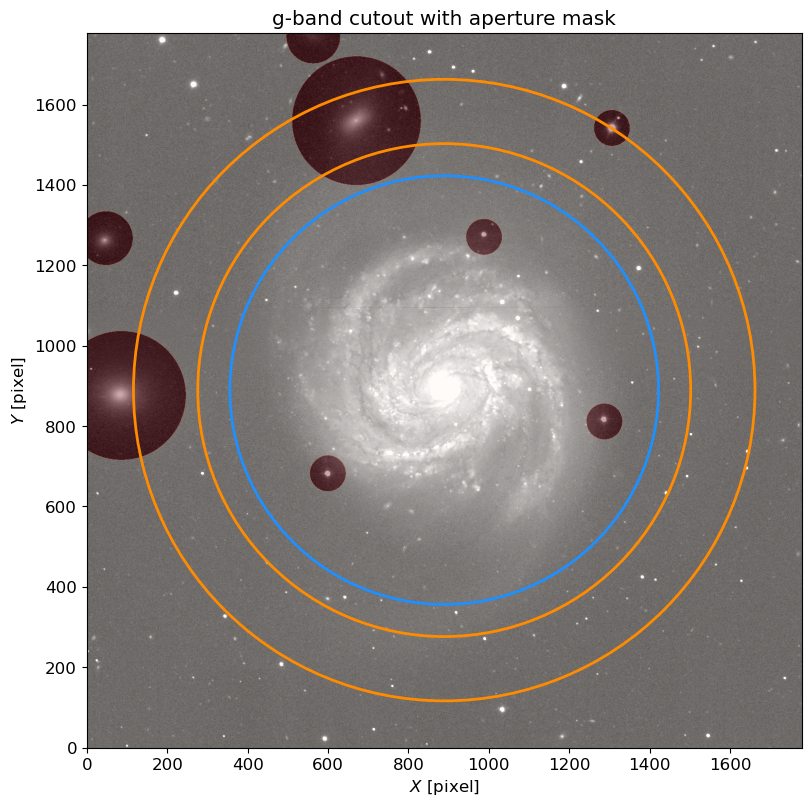

In [22]:
# Choose a band to inspect
inspect_band = 'g'

data = cutout_images[inspect_band]
mask = cutout_masks_aperture[inspect_band]
wcs = cutout_wcs[inspect_band]

# Convert galaxy center to cutout pixel coordinates
x_center, y_center = wcs.world_to_pixel(target_coord)

# Convert aperture radius to pixels for this band
pixscale_arcsec = cutout_pixscale_arcsec[inspect_band]
aperture_radius_pix = aperture_radius.to(u.arcsec).value / pixscale_arcsec
annulus_inner_pix = bkg_annulus_inner_radius.to(u.arcsec).value / pixscale_arcsec
annulus_outer_pix = bkg_annulus_outer_radius.to(u.arcsec).value / pixscale_arcsec

# Create a Photutils circular aperture in pixel coordinates
aperture = CircularAperture((x_center, y_center), r=aperture_radius_pix)
annulus = CircularAnnulus((x_center, y_center), r_in=annulus_inner_pix, r_out=annulus_outer_pix)

norm = ImageNormalize(data, interval=PercentileInterval(99.5), stretch=AsinhStretch())

plt.figure(figsize=(8,8), constrained_layout=True)
plt.imshow(data, origin='lower', cmap='gray', norm=norm)
plt.imshow(mask, origin='lower', cmap='Reds', alpha=0.35)
aperture.plot(color='dodgerblue', lw=2)
annulus.plot(color='darkorange', lw=2)
plt.title(f'{inspect_band}-band cutout with aperture mask')
plt.xlabel(r'$X$ [pixel]')
plt.ylabel(r'$Y$ [pixel]')
plt.show()

## 8. Aperture Photometry with Local Background Subtraction

Now we are ready to measure the integrated flux in each band. For each image, we'll
1. Create a circular aperture centered on NGC 4321.
2. Create a circular annulus around the aperture.
3. Apply the image mask and any additional manually supplied masks.
4. Measure the raw aperture flux. 
5. Estimate the local residual background using the sigma-clipped median value in the annulus. 
6. Subtract the local background contribution from the raw aperture flux. 
7. Propagate uncertainties. 

Again, the background-corrected flux is $$F_{\rm corr} = F_{\rm raw} - B_{\rm local} \times N_{\rm aper},$$ where $F_{\rm raw}$ is the raw aperture flux, $B_{\rm local}$ is the sigma-clipped median annulus value, and $N_{\rm aper}$ is the effective number of unmasked pixels in the aperture. 

The random uncertainty has two pieces: $$\sigma_{\rm random}^2 = \sigma_{\rm aper}^2 + \left(N_{\rm aper} \times \sigma_{B}\right)^2,$$ where $\sigma_{\rm aper}$ is the aperture uncertainty from the pixel uncertainty image and $\sigma_{B}$ is the uncertainty in the estimated local background level. 

Finally, we add the calibration uncertainty, $$\sigma_{\rm total} = \sqrt{\sigma_{\rm random}^2 + \sigma_{\rm cal}^2}.$$ Here, the calibration term is $$\sigma_{\rm cal} = f_{\rm cal} \times |F_{\rm corr}|.$$ Since the calibration uncertainty is not independent pixel-by-pixel noise, we add it in quadrature only after measuring the total aperture flux. 

In [23]:
# This QTable will store the final photometry
# QTable is useful because it can store Astropy Quantity columns with units.
photometry_table = QTable(
    names=['id','band','instrument','cigale_filter','wavelength','aperture_radius','bkg_annulus_inner_radius','bkg_annulus_outer_radius',
           'raw_flux_density_jy','local_bkg_jy_pix','local_bkg_unc_jy_pix','local_bkg_flux_jy','flux_density_jy','flux_density_mjy',
           'aperture_random_unc_jy','local_bkg_random_unc_jy','random_unc_jy','calibration_unc_jy','total_unc_jy','total_unc_mjy',
           'flux_density_cgs_fnu','total_unc_cgs_fnu','flux_density_cgs_flambda','total_unc_cgs_flambda','ab_mag','ab_mag_unc',
           'calibration_percent','masked_fraction_aperture','masked_fraction_annulus','aperture_area_pix',
           'unmasked_aperture_area_pix','annulus_area_pix','unmasked_annulus_area_pix','notes'],
    dtype=['U30','U20','U20','U40',object,object,object,object,object,object,object,object,object,object,object,object,
           object,object,object,object,object,object,object,object,object,object,float,float,float,float,
           float,float,float,'U150'],
    units=[None,None,None,None,u.um,u.arcmin,u.arcmin,u.arcmin,u.Jy,u.Jy,u.Jy,u.Jy,u.Jy,u.mJy,u.Jy,u.Jy,u.Jy,u.Jy,u.Jy,u.mJy,
           u.erg/u.s/u.cm**2/u.Hz, u.erg/u.s/u.cm**2/u.Hz, u.erg/u.s/u.cm**2/u.AA, u.erg/u.s/u.cm**2/u.AA, u.ABmag, u.ABmag,
           None,None,None,None,None,None,None,None]
)

for row in image_table:
    band = row['band']
    instrument = row['instrument']
    cigale_filter = row['cigale_filter']
    wavelength = row['wavelength_um'] * u.um

    print(f'Photometry for {band}...')

    data = cutout_images[band]
    sigma_bkg = cutout_sigma_bkg[band]
    mask = cutout_masks_aperture[band]
    wcs = cutout_wcs[band]

    # Pixel scale for this cutout
    pixscale_arcsec = cutout_pixscale_arcsec[band]

    # Convert aperture and annulus radii from angular units to pixels
    aperture_radius_pix = aperture_radius.to(u.arcsec).value / pixscale_arcsec
    annulus_inner_pix = bkg_annulus_inner_radius.to(u.arcsec).value / pixscale_arcsec
    annulus_outer_pix = bkg_annulus_outer_radius.to(u.arcsec).value / pixscale_arcsec

    # Galaxy center in cutout pixel coordinates
    x_center, y_center = wcs.world_to_pixel(target_coord)

    # Define the aperture and annulus in pixel coordinates
    aperture = CircularAperture((x_center, y_center), r=aperture_radius_pix)
    annulus = CircularAnnulus((x_center, y_center), r_in=annulus_inner_pix, r_out=annulus_outer_pix)

    # Make a combined mask
    # True means do not use
    phot_mask = (
        mask |
        (~np.isfinite(data)) |
        (~np.isfinite(sigma_bkg))
    )

    # Photutils cannot meaningfully sum NaNs.
    # We replace masked pixels with zero, but also provide the mask to
    # aperture photometry so those pixels do not contribute
    data_for_phot = np.array(data, copy=True)
    data_for_phot[phot_mask] = 0.0

    sigma_for_phot = np.array(sigma_bkg, copy=True)
    sigma_for_phot[phot_mask] = 0.0

    # Attach units
    # The images are in flux densities per pixel, Jy/pix
    # Since aperture photometry sums over pixels, the aperture sum is Jy
    data_quantity = data_for_phot * u.Jy
    error_quantity = sigma_for_phot * u.Jy

    # RAW APERTURE PHOTOMETRY
    #
    # This gives the total flux inside the aperture before local background subtraction
    raw_phot = aperture_photometry(data_quantity, aperture, error=error_quantity, mask=phot_mask, method='exact')

    raw_flux_jy = raw_phot['aperture_sum'][0]

    if 'aperture_sum_err' in raw_phot.colnames:
        aperture_random_unc_jy = raw_phot['aperture_sum_err'][0]
    else:
        aperture_random_unc_jy = np.nan * u.Jy
    
    # EFFECTIVE APERTURE AND ANNULUS AREAS
    #
    # The exact aperture mask accounts for fractional pixels at the edge of the aperture or annulus
    aperture_weight_image = aperture.to_mask(method='exact').to_image(data.shape)
    annulus_weight_image = annulus.to_mask(method='exact').to_image(data.shape)

    if aperture_weight_image is None:
        raise ValueError(f'Aperture is outside the cutout for {band}.')
    if annulus_weight_image is None:
        raise ValueError(f'Background annulus is outside the cutout for {band}.')
    
    # Pixels contributing to the aperture or annulus
    in_aperture = aperture_weight_image > 0
    in_annulus = annulus_weight_image > 0

    good_aperture = in_aperture & (~phot_mask)
    good_annulus = in_annulus & (~phot_mask)

    # Effective areas in pixels
    aperture_area_pix = np.nansum(aperture_weight_image[in_aperture])
    unmasked_aperture_area_pix = np.nansum(aperture_weight_image[good_aperture])

    annulus_area_pix = np.nansum(annulus_weight_image[in_annulus])
    unmasked_annulus_area_pix = np.nansum(annulus_weight_image[good_annulus])

    masked_fraction_aperture = 1.0 - (unmasked_aperture_area_pix / aperture_area_pix)
    masked_fraction_annulus = 1.0 - (unmasked_annulus_area_pix / annulus_area_pix)

    # LOCAL RESIDUAL BACKGROUND FROM ANNULUS
    #
    # We use the actual pixel values in the annulus
    # The images are already globally background subtracted, so this
    # measures any remaining local residual background level.
    annulus_values = data[good_annulus]

    if len(annulus_values) < 20:
        local_bkg_jy_pix = np.nan * u.Jy
        local_bkg_unc_jy_pix = np.nan * u.Jy
        local_bkg_flux_jy = np.nan * u.Jy
        local_bkg_random_unc_jy = np.nan * u.Jy
        corrected_flux_jy = np.nan * u.Jy
        random_unc_jy = np.nan * u.Jy
        notes = 'Too few unmasked pixels in background annulus'
    else:
        # Sigma clip the annulus pixels to reject outliers
        clipped_annulus = sigma_clip(annulus_values, sigma=3.0, maxiters=5, masked=True)
        clipped_values = clipped_annulus.compressed()

        if len(clipped_values) < 20:
            local_bkg_jy_pix = np.nan * u.Jy
            local_bkg_unc_jy_pix = np.nan * u.Jy
            local_bkg_flux_jy = np.nan * u.Jy
            local_bkg_random_unc_jy = np.nan * u.Jy
            corrected_flux_jy = np.nan * u.Jy
            random_unc_jy = np.nan * u.Jy
            notes = 'Too few pixels after sigma clipping in background annulus'
        else:
            # Sigma-clipped median background level in Jy/pix
            local_bkg_value = np.nanmedian(clipped_values)
            local_bkg_jy_pix = local_bkg_value * u.Jy

            # Scatter of the annulus pixels
            # This measures how much the local sky varies from pixel to pixel
            annulus_std_value = np.nanstd(clipped_values, ddof=1)

            # Effective number of background pixels
            # This uses the unmasked annulus area from the exact annulus mask
            n_bkg_eff = unmasked_annulus_area_pix

            # Approximate uncertainty on the median
            # For Gaussian noise, the standard error of the median is about
            # 1.253 times the standard error of the mean
            local_bkg_unc_value = 1.253 * annulus_std_value / np.sqrt(n_bkg_eff)
            local_bkg_unc_jy_pix = local_bkg_unc_value * u.Jy

            # Total residual background contribution inside the aperture
            local_bkg_flux_jy = local_bkg_jy_pix * unmasked_aperture_area_pix

            # Uncertainty in the background contribution
            local_bkg_random_unc_jy = local_bkg_unc_jy_pix * unmasked_aperture_area_pix

            # Subtract the local residual background contribution
            corrected_flux_jy = raw_flux_jy - local_bkg_flux_jy

            # Combine aperture random uncertainty and local-background uncertainty
            random_unc_jy = np.sqrt(aperture_random_unc_jy**2 + local_bkg_random_unc_jy**2)

            notes = ''
    
    # CALIBRATION UNCERTAINTY
    # Calibration uncertainty is a fractional uncertainty on the total flux.
    # It should be applied after the aperture flux is measured and after
    # local background subtraction
    cal_percent = calibration_percent[band]

    if np.isfinite(cal_percent):
        cal_fraction = cal_percent / 100.0
        calibration_unc_jy = cal_fraction * np.abs(corrected_flux_jy)
    else:
        cal_fraction = 0.0
        calibration_unc_jy = 0.0 * u.Jy

        if notes == '':
            notes = 'Missing CALPCT; calibration uncertainty set to zero'
        else:
            notes = notes + '; missing CALPCT'
    
    # Total uncertainty
    total_unc_jy = np.sqrt(random_unc_jy**2 + calibration_unc_jy**2)

    # UNIT CONVERSIONS
    # Convert Jy to mJy
    flux_mjy = corrected_flux_jy.to(u.mJy)
    total_unc_mjy = total_unc_jy.to(u.mJy)

    # Convert Jy to cgs F_nu
    flux_cgs_fnu = corrected_flux_jy.to(u.erg/u.s/u.cm**2/u.Hz)
    total_unc_cgs_fnu = total_unc_jy.to(u.erg/u.s/u.cm**2/u.Hz)

    # Convert Jy to cgs F_lambda
    flux_cgs_flambda = corrected_flux_jy.to(u.erg/u.s/u.cm**2/u.AA, equivalencies=u.spectral_density(wavelength))
    total_unc_cgs_flambda = total_unc_jy.to(u.erg/u.s/u.cm**2/u.AA, equivalencies=u.spectral_density(wavelength))

    # Conver to AB magnitude
    if corrected_flux_jy > 0 * u.Jy and total_unc_jy > 0 * u.Jy:
        ab_mag_value = corrected_flux_jy.to(u.ABmag)
        ab_mag_unc = (
            (2.5 / np.log(10)) *
            (total_unc_jy / corrected_flux_jy).decompose().value * u.ABmag
        )
    else:
        ab_mag_value = np.nan * u.ABmag
        ab_mag_unc = np.nan * u.ABmag

        if notes == '':
            notes = 'Non-positive background-subtracted flux; AB mag undefined'
        else:
            notes = notes + '; non-positive flux'
    
    # Add warnings for large masked fractions
    if np.isfinite(masked_fraction_aperture) and masked_fraction_aperture > 0.10:
        if notes == '':
            notes = 'Large masked fraction in aperture'
        else:
            notes = notes + '; large masked fraction in aperture'
    
    if np.isfinite(masked_fraction_annulus) and masked_fraction_annulus > 0.20:
        if notes == '':
            notes = 'Large masked fraction in background annulus'
        else:
            notes = notes + '; large masked fraction in background annulus'

    photometry_table.add_row(
        [target_name, band, instrument, cigale_filter, wavelength.value, aperture_radius.value, bkg_annulus_inner_radius.value, bkg_annulus_outer_radius.value,
         raw_flux_jy.value, local_bkg_jy_pix.value, local_bkg_unc_jy_pix.value, local_bkg_flux_jy.value, corrected_flux_jy.value, flux_mjy.value, aperture_random_unc_jy.value,
         local_bkg_random_unc_jy.value, random_unc_jy.value, calibration_unc_jy.value, total_unc_jy.value, total_unc_mjy.value, flux_cgs_fnu.value, total_unc_cgs_fnu.value,
         flux_cgs_flambda.value, total_unc_cgs_flambda.value, ab_mag_value.value, ab_mag_unc.value, cal_percent, masked_fraction_aperture, masked_fraction_annulus,
         aperture_area_pix, unmasked_aperture_area_pix, annulus_area_pix, unmasked_annulus_area_pix, notes]
    )

photometry_table

Photometry for FUV...
Photometry for NUV...
Photometry for u...
Photometry for g...
Photometry for r...
Photometry for i...
Photometry for z...
Photometry for J...
Photometry for H...
Photometry for Ks...
Photometry for IRAC1...
Photometry for IRAC2...
Photometry for IRAC3...
Photometry for IRAC4...
Photometry for MIPS24...
Photometry for MIPS160...
Photometry for W1...
Photometry for W2...
Photometry for W3...
Photometry for W4...


id,band,instrument,cigale_filter,wavelength,aperture_radius,bkg_annulus_inner_radius,bkg_annulus_outer_radius,raw_flux_density_jy,local_bkg_jy_pix,local_bkg_unc_jy_pix,local_bkg_flux_jy,flux_density_jy,flux_density_mjy,aperture_random_unc_jy,local_bkg_random_unc_jy,random_unc_jy,calibration_unc_jy,total_unc_jy,total_unc_mjy,flux_density_cgs_fnu,total_unc_cgs_fnu,flux_density_cgs_flambda,total_unc_cgs_flambda,ab_mag,ab_mag_unc,calibration_percent,masked_fraction_aperture,masked_fraction_annulus,aperture_area_pix,unmasked_aperture_area_pix,annulus_area_pix,unmasked_annulus_area_pix,notes
,,,,um,arcmin,arcmin,arcmin,Jy,Jy,Jy,Jy,Jy,mJy,Jy,Jy,Jy,Jy,Jy,mJy,erg / (Hz s cm2),erg / (Hz s cm2),erg / (Angstrom s cm2),erg / (Angstrom s cm2),mag(AB),mag(AB),,,,,,,,
str30,str20,str20,str40,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,str150
NGC4321,FUV,GALEX,galex.FUV,0.153508,4.0,4.6,5.8,0.031293724597170475,2.779232756053976e-08,5.927218790123084e-10,0.00048090326868323725,0.030812821328487238,30.81282132848724,5.879564868390727e-06,1.0256135921548325e-05,1.1821912158483008e-05,0.0013865769597819256,0.0013866273554943198,1.3866273554943198,3.0812821328487237e-25,1.3866273554943198e-26,3.9200367782622806e-13,1.7640806641282537e-14,12.678171335894097,0.048859904983005256,4.5,0.020824545315581533,0.11520636709786947,17671.45425857875,17303.45425857875,13783.734321691416,12195.760365447131,
NGC4321,NUV,GALEX,galex.NUV,0.230078,4.0,4.6,5.8,0.05368558369122743,4.0439420956070675e-08,7.390885079795854e-10,0.0006997416707567798,0.05298584202047065,52.98584202047065,7.473968703176146e-06,1.278878419086597e-05,1.4812603054716612e-05,0.0014306177345527079,0.0014306944172764423,1.4306944172764422,5.298584202047065e-25,1.4306944172764423e-26,3.000753740725196e-13,8.102469378175231e-15,12.089600399290072,0.029316448838960438,2.7,0.020824545315581533,0.11520636709786947,17671.45425857875,17303.45425857875,13783.734321691416,12195.760365447131,
NGC4321,u,SDSS,sloan.sdss.u,0.350102,4.0,4.6,5.8,0.18854066802541083,1.1736926024572152e-08,2.364244964474749e-10,0.010269734885472385,0.17827093313993844,178.27093313993845,0.00013935559449145468,0.00020686991584198758,0.0002494296369650924,0.0023175221308192,0.0023309062552220546,2.3309062552220547,1.7827093313993845e-24,2.3309062552220546e-26,4.3602566911665163e-13,5.701069387366624e-15,10.772298655606264,0.01419608495124216,1.3,0.020831268274141723,0.11526650387304849,893608.577021097,874993.5770210965,697014.6900764551,616672.2436031858,
NGC4321,g,SDSS,sloan.sdss.g,0.476311,4.0,4.6,5.8,0.4807979174493533,1.3756151913049689e-08,9.157832697093492e-11,0.012036544568444947,0.46876137288090836,468.76137288090837,5.284883188869346e-05,8.01304478939059e-05,9.598899786786689e-05,0.003750090983047267,0.003751319270449277,3.751319270449277,4.687613728809083e-24,3.751319270449277e-26,6.194286632144938e-13,4.95705238403999e-15,9.722620456189864,0.008688734574058832,0.8,0.020831268274141723,0.11526650387304849,893608.577021097,874993.5770210965,697014.6900764551,616672.2436031858,
NGC4321,r,SDSS,sloan.sdss.r,0.624698,4.0,4.6,5.8,0.8047126492842446,2.554723212001719e-08,1.4180420551459992e-10,0.02235366401568209,0.7823589852685625,782.3589852685625,8.106987674501873e-05,0.0001240777690198545,0.00014821476876612834,0.0062588718821485,0.006260626554493528,6.260626554493529,7.823589852685624e-24,6.260626554493528e-26,6.010167096955656e-13,4.80948163600721e-15,9.166484813171394,0.00868832472391227,0.8,0.020831268274141723,0.11526650387304849,893608.577021097,874993.5770210965,697014.6900764551,616672.2436031858,
NGC4321,i,SDSS,sloan.sdss.i,0.771828,4.0,4.6,5.8,1.088727162056013,3.6482526535495206e-08,2.31248127785497e-10,0.03192197639206002,1.056805185663953,1056.8051856639531,0.00013338286762661964,0.00020234062651046364,0.00024234834126304078,0.007397636299647671

## 9. Inspect the Photometry Table

The most important columns for SED fitting are usually: 
- `band`
- `flux_density_mjy`
- `total_unc_mjy`

The cgs flux density columns were calculated because they are often useful in some codes and for comparing with papers. 

For CIGALE, we will have a separate file with one row:
```text
id redshift dist filter1 filter1_err filter2 filter2_err ...
```
with fluxes and uncertainties only.

In [24]:
# Display a compact version of the photometry table

photometry_table['wavelength'].info.format = '{:.3f}'
photometry_table['flux_density_mjy'].info.format = '{:.3f}'
photometry_table['total_unc_mjy'].info.format = '{:.3f}'
photometry_table['ab_mag'].info.format = '{:.3f}'
photometry_table['ab_mag_unc'].info.format = '{:.3f}'
photometry_table['masked_fraction_aperture'].info.format = '{:.3f}'
photometry_table['masked_fraction_annulus'].info.format = '{:.3f}'
photometry_table['band','instrument','wavelength','flux_density_mjy','total_unc_mjy','ab_mag','ab_mag_unc',
                 'masked_fraction_aperture','masked_fraction_annulus','notes'].pprint_all()

  band  instrument wavelength flux_density_mjy total_unc_mjy  ab_mag ab_mag_unc masked_fraction_aperture masked_fraction_annulus notes
                       um           mJy             mJy      mag(AB)  mag(AB)                                                         
------- ---------- ---------- ---------------- ------------- ------- ---------- ------------------------ ----------------------- -----
    FUV      GALEX      0.154           30.813         1.387  12.678      0.049                    0.021                   0.115      
    NUV      GALEX      0.230           52.986         1.431  12.090      0.029                    0.021                   0.115      
      u       SDSS      0.350          178.271         2.331  10.772      0.014                    0.021                   0.115      
      g       SDSS      0.476          468.761         3.751   9.723      0.009                    0.021                   0.115      
      r       SDSS      0.625          782.359         

## 10. Plot the SED

We're not fitting yet. We're just seeing what the observed SED plot looks like. We'll plot $F_\nu$ in mJy versus wavelength in microns. 

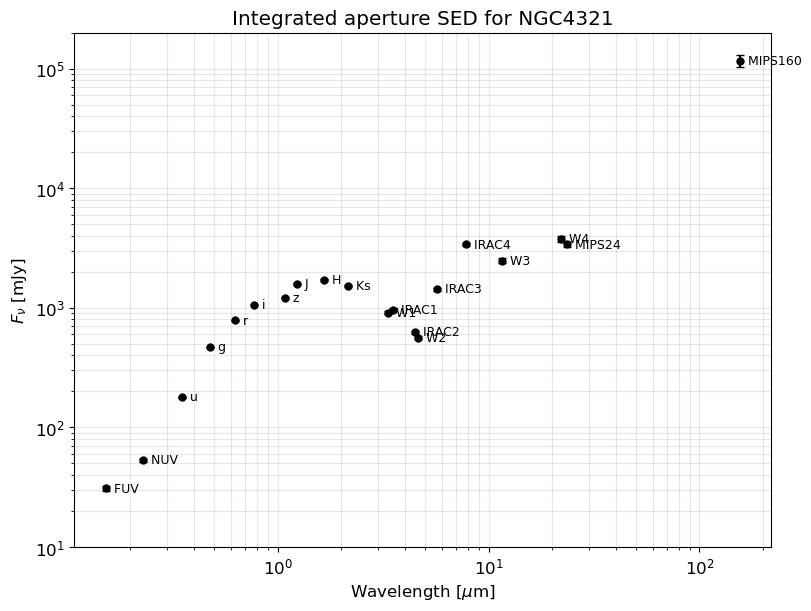

In [25]:
%matplotlib inline

wavelength_um = np.array(photometry_table['wavelength'].to(u.um).value, dtype=float)
flux_mjy = np.array(photometry_table['flux_density_mjy'].to(u.mJy).value, dtype=float)
unc_mjy = np.array(photometry_table['total_unc_mjy'].to(u.mJy).value, dtype=float)

good = (
    np.isfinite(wavelength_um) &
    np.isfinite(flux_mjy) & 
    np.isfinite(unc_mjy) & 
    (flux_mjy > 0) & 
    (unc_mjy > 0)
)

plt.figure(figsize=(8,6), constrained_layout=True)

plt.xscale('log')
plt.yscale('log')

plt.errorbar(wavelength_um[good], flux_mjy[good],
             yerr=unc_mjy[good],
             color='k', ls='None', marker='o', ms=5, capsize=3)

for row in photometry_table[good]:
    plt.text(row['wavelength'], row['flux_density_mjy'], f'  {row['band']}',
             fontsize=9, va='center')


plt.xlabel(r'Wavelength [$\mu$m]')
plt.ylabel(r'$F_\nu$ [mJy]')
plt.ylim(1e1,2e5)
plt.title(f'Integrated aperture SED for {target_name}')
plt.grid(alpha=0.3, which='both')
plt.show()

## 11. Save the Full Photometry Table

We'll save the full photometry table as an ECSV file. 

In [26]:
photometry_table.write(output_dir / 'NGC4321_aperture_photometry.ecsv', format='ascii.ecsv', overwrite=True)
image_table.write(output_dir / 'NGC4321_aperphot_imagetable.ecsv', format='ascii.ecsv', overwrite=True)
aperture_mask_regions.write(output_dir / 'NGC4321_aperture_mask.ecsv', format='ascii.ecsv', overwrite=True)

## 12. Create a CIGALE-Formatted Input File

CIGALE expects broadband fluxes and uncertainties in mJy. The input file should contain
- `id`
- `redshift`
- optionally `dist`, for distance in Mpc
- one column for each filter flux
- one matching error column for each filter, with `_err` appended

For example,
```text
id redshift dist FUV FUV_err NUV NUV_err ...
NGC4321 0.0 15.2 ...
```

In [27]:
# Selected bands that have valid positive fluxes and uncertainties
valid_for_cigale = (
    np.isfinite(np.array(photometry_table['flux_density_mjy'].to(u.mJy).value, dtype=float)) & 
    np.isfinite(np.array(photometry_table['total_unc_mjy'].to(u.mJy).value, dtype=float)) & 
    (photometry_table['flux_density_mjy'] > 0 * u.mJy) & 
    (photometry_table['total_unc_mjy'] > 0 * u.mJy)
)

cigale_phot = photometry_table[valid_for_cigale]

# Start a one-row table for CIGALE
cigale_table = Table()

cigale_table['id'] = [target_name]
cigale_table['redshift'] = [galaxy_redshift]
cigale_table['distance'] = [galaxy_distance_mpc]

for row in cigale_phot:
    filter_name = row['cigale_filter']

    flux_mjy_value = row['flux_density_mjy']
    unc_mjy_value = row['total_unc_mjy']

    cigale_table[filter_name] = [flux_mjy_value]
    cigale_table[f'{filter_name}_err'] = [unc_mjy_value]

cigale_table

id,redshift,distance,galex.FUV,galex.FUV_err,galex.NUV,galex.NUV_err,sloan.sdss.u,sloan.sdss.u_err,sloan.sdss.g,sloan.sdss.g_err,sloan.sdss.r,sloan.sdss.r_err,sloan.sdss.i,sloan.sdss.i_err,sloan.sdss.z,sloan.sdss.z_err,2mass.J,2mass.J_err,2mass.H,2mass.H_err,2mass.Ks,2mass.Ks_err,spitzer.irac.I1,spitzer.irac.I1_err,spitzer.irac.I2,spitzer.irac.I2_err,spitzer.irac.I3,spitzer.irac.I3_err,spitzer.irac.I4,spitzer.irac.I4_err,spitzer.mips.24mu,spitzer.mips.24mu_err,spitzer.mips.160mu,spitzer.mips.160mu_err,wise.W1,wise.W1_err,wise.W2,wise.W2_err,wise.W3,wise.W3_err,wise.W4,wise.W4_err
str7,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
NGC4321,0.0,15.8,30.81282132848724,1.3866273554943198,52.98584202047065,1.4306944172764422,178.27093313993845,2.3309062552220547,468.76137288090837,3.751319270449277,782.3589852685625,6.260626554493529,1056.8051856639531,7.401604930039014,1213.102908240968,9.73740401172521,1587.5526725754069,27.096792773722676,1715.5382731768525,32.8608013773628,1527.8591949918095,29.298166900122624,964.3310728784578,28.93013377287502,624.3607271010943,18.731364669980444,1427.7846945051272,42.83895288786623,3388.894916750028,101.67092639207894,3382.0001702832806,169.10359606226098,116886.71694098745,14026.567753119496,907.9352005381191,26.33050722913436,562.7516354458583,19.13413469981618,2479.0179171533746,114.03573210384826,3766.4545903596195,210.9251872933513


In [28]:
cigale_table.write(output_dir / 'NGC4321_cigale_input.txt', format='ascii.basic', overwrite=True)